In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from torchvision.models import resnet50, ResNet50_Weights

from IntegratedGradients import IntegratedGradients

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\tvysi/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
preprocess = weights.transforms()

In [4]:
img = Image.open("../Pictures/Indian_Cobra.jpg").convert("RGB")
input_tensor = preprocess(img).unsqueeze(0).to(device)

In [5]:
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.nn.functional.softmax(output, dim=1)

pred_class = torch.argmax(probs, dim=1).item()
confidence = probs[0, pred_class].item()

print("Predicted class:", pred_class)
print("Confidence:", confidence)

labels = weights.meta["categories"]
print("Class name:", labels[pred_class])

Predicted class: 63
Confidence: 0.32439595460891724
Class name: Indian cobra


In [28]:
ig = IntegratedGradients(model, device=device)

attributions = ig.explain(
    inputs=input_tensor,
    target=pred_class,
    steps=10
)

In [29]:
attr = attributions.squeeze().detach().cpu().numpy()

attr = np.sum(attr, axis=0)

attr = (attr - attr.min()) / (attr.max() - attr.min())

In [21]:
def ig_to_heatmap(attributions, mode="abs", clip_percentile=99.5, eps=1e-8):
    """
    attributions: torch.Tensor (1, C, H, W) alebo (C, H, W)
    mode:
      - "abs": zvýrazní aj + aj - (najčitateľnejšie)
      - "pos": len pozitívne príspevky
      - "neg": len negatívne príspevky
    """
    if hasattr(attributions, "detach"):
        attr = attributions.detach().cpu().numpy()
    else:
        attr = np.array(attributions)

    if attr.ndim == 4:
        attr = attr[0]  # (C,H,W)

    if mode == "abs":
        heat = np.sum(np.abs(attr), axis=0)
    elif mode == "pos":
        heat = np.sum(np.maximum(attr, 0), axis=0)
    elif mode == "neg":
        heat = np.sum(np.maximum(-attr, 0), axis=0)
    else:
        raise ValueError("mode must be one of: abs, pos, neg")

    # robust scaling: clip outliers
    hi = np.percentile(heat, clip_percentile)
    heat = np.clip(heat, 0, hi)

    # normalize to [0,1]
    heat = (heat - heat.min()) / (heat.max() - heat.min() + eps)
    return heat

def show_overlay(img_pil, heat, title="", alpha=0.45, cmap="inferno"):
    plt.figure(figsize=(6,6))
    plt.imshow(img_pil)
    plt.imshow(heat, cmap=cmap, alpha=alpha)
    plt.title(title)
    plt.axis("off")
    plt.show()

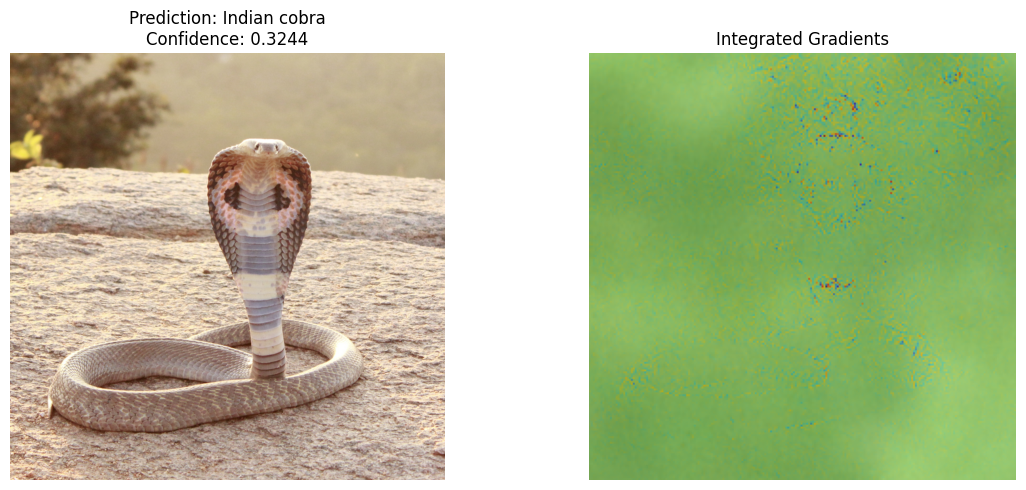

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Prediction: {labels[pred_class]}\nConfidence: {confidence:.4f}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img)
plt.imshow(attr, cmap="jet", alpha=0.5)
plt.title("Integrated Gradients")
plt.axis("off")

plt.tight_layout()
plt.show()

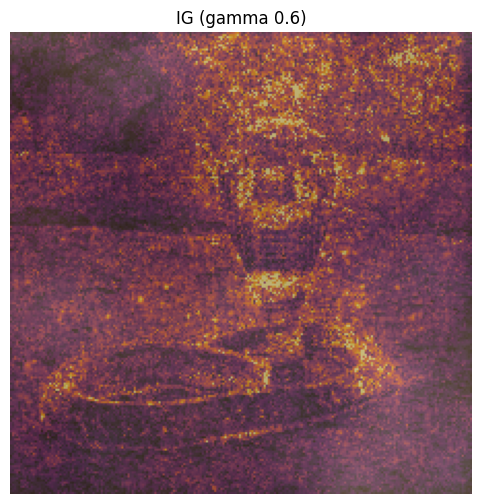

In [31]:
heat = ig_to_heatmap(attributions, mode="abs", clip_percentile=99.0)
heat = heat ** 0.6   # gamma < 1 zvýrazní slabšie oblasti
show_overlay(img, heat, title="IG (gamma 0.6)", alpha=0.5, cmap="inferno")

In [9]:
baseline = torch.zeros_like(input_tensor).to(device)

with torch.no_grad():
    pred_input = model(input_tensor)[0, pred_class]
    pred_base = model(baseline)[0, pred_class]

ig_sum = attributions.sum()

print("F(x) - F(x'):", (pred_input - pred_base).item())
print("Sum IG:", ig_sum.item())

F(x) - F(x'): 5.936908721923828
Sum IG: -1.4340646266937256
